# Amazon Sales Analytics Platform

## Python Data Cleaning, Feature Engineering & Exploratory Data Analysis

### Project Objective

The objective of this notebook is to clean the Amazon Sales dataset, engineer meaningful features, perform exploratory data analysis (EDA), detect outliers, and generate business insights that support data-driven decision-making.

---

### Business Problem

Organizations need meaningful insights from sales data to understand customer purchasing behavior, product performance, revenue trends, and regional sales distribution.

This notebook transforms raw sales data into actionable business intelligence by applying data cleaning techniques, feature engineering, statistical analysis, and visualization.

---

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

---

### Dataset

**Amazon Sales Dataset**

- Records: 100,000
- Features: 19

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_csv("../Dataset/Amazon_Sales_Data.csv")



## Date Format Conversion

In [7]:
dataset["OrderDate"] = pd.to_datetime(dataset["OrderDate"], dayfirst=True)
dataset["OrderDate"].head()

0   2023-01-31
1   2023-12-30
2   2022-05-10
3   2023-07-18
4   2023-02-04
Name: OrderDate, dtype: datetime64[ns]

## Feature Engineering

In [8]:
dataset["Year"] = dataset["OrderDate"].dt.year
dataset["Month"] = dataset["OrderDate"].dt.month_name()
dataset["Quarter"] = dataset["OrderDate"].dt.quarter
dataset["Day"] = dataset["OrderDate"].dt.day_name()
dataset.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,PaymentMethod,OrderStatus,City,State,Country,SellerID,Year,Month,Quarter,Day
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3.0,106.59,...,Debit Card,Delivered,Washington,DC,India,SELL01967,2023,January,1,Tuesday
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1.0,251.37,...,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,2023,December,4,Saturday
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,NaN,35.03,...,Debit Card,Delivered,Austin,TX,United States,SELL00908,2022,May,2,Tuesday
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5.0,33.58,...,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,2023,July,3,Tuesday
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2.0,515.64,...,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,2023,February,1,Saturday


## Correlation Analysis

In [9]:
# ============================================================
# Correlation Analysis
# ============================================================

correlation_matrix = dataset.corr(numeric_only=True)
correlation_matrix

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,Year,Quarter
Quantity,1.000000,0.004408,-0.000398,0.437885,0.020047,0.594932,0.001273,0.002524
UnitPrice,0.004408,1.000000,0.006159,0.526856,0.045773,0.715808,-0.003369,-0.001158
Discount,-0.000398,0.006159,1.000000,-0.077550,0.000315,-0.108088,-0.001525,0.000485
Tax,0.437885,0.526856,-0.077550,1.000000,0.023498,0.779399,-0.004556,0.001438
ShippingCost,0.020047,0.045773,0.000315,0.023498,1.000000,0.039349,-0.002438,-0.003673
TotalAmount,0.594932,0.715808,-0.108088,0.779399,0.039349,1.000000,-0.002847,0.001614
Year,0.001273,-0.003369,-0.001525,-0.004556,-0.002438,-0.002847,1.000000,-0.005541
Quarter,0.002524,-0.001158,0.000485,0.001438,-0.003673,0.001614,-0.005541,1.000000


In [10]:
correlation_matrix["TotalAmount"].sort_values(ascending=False)

TotalAmount     1.000000
Tax             0.779399
UnitPrice       0.715808
Quantity        0.594932
ShippingCost    0.039349
Quarter         0.001614
Year           -0.002847
Discount       -0.108088
Name: TotalAmount, dtype: float64

### Box Plot — Quantity

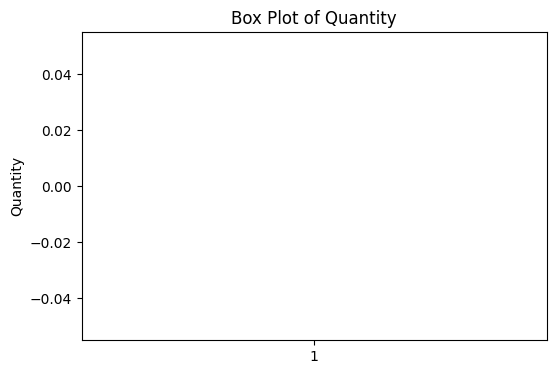

In [12]:
plt.figure(figsize=(6,4))

plt.boxplot(dataset["Quantity"])

plt.title("Box Plot of Quantity")

plt.ylabel("Quantity")

plt.show()

### Box Plot — Totak Amount

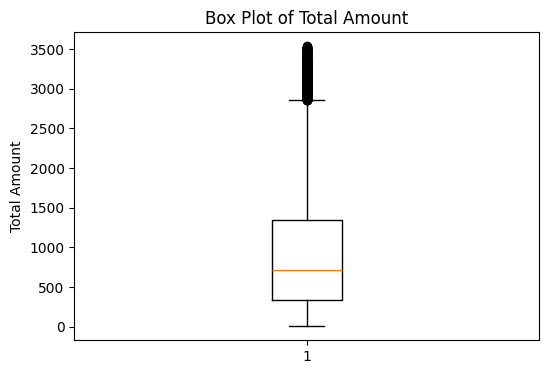

In [13]:
plt.figure(figsize=(6,4))

plt.boxplot(dataset["TotalAmount"])

plt.title("Box Plot of Total Amount")

plt.ylabel("Total Amount")

plt.show()

### Box Plot — Unit Price

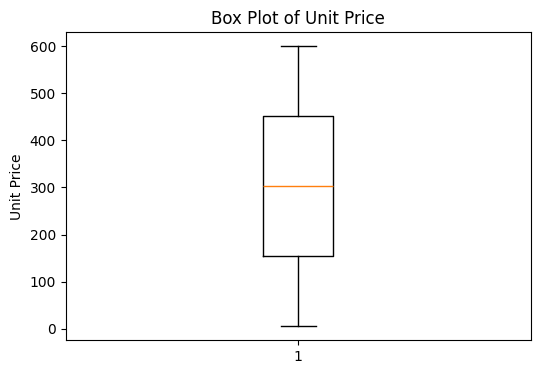

In [14]:
plt.figure(figsize=(6,4))

plt.boxplot(dataset["UnitPrice"])

plt.title("Box Plot of Unit Price")

plt.ylabel("Unit Price")

plt.show()

### Box Plot — Discount

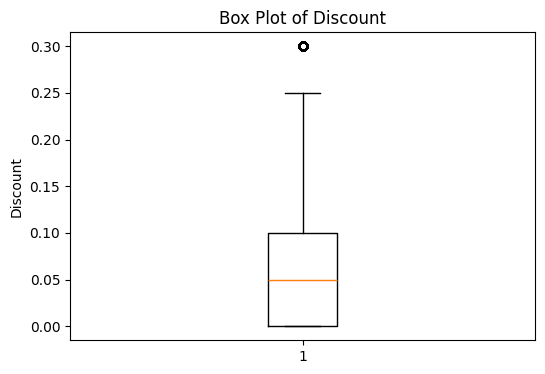

In [15]:
plt.figure(figsize=(6,4))

plt.boxplot(dataset["Discount"])

plt.title("Box Plot of Discount")

plt.ylabel("Discount")

plt.show()

### Box Plot — Tax

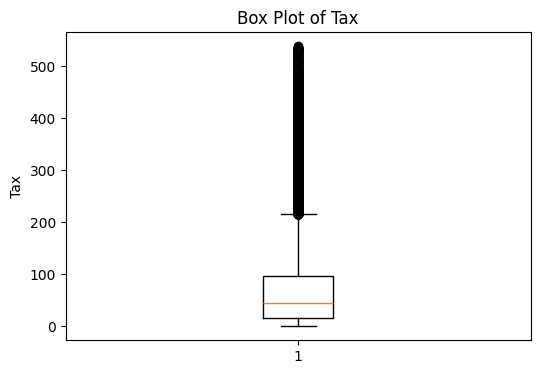

In [16]:
plt.figure(figsize=(6,4))

plt.boxplot(dataset["Tax"])

plt.title("Box Plot of Tax")

plt.ylabel("Tax")

plt.show()

### Box Plot — Shipping Cost

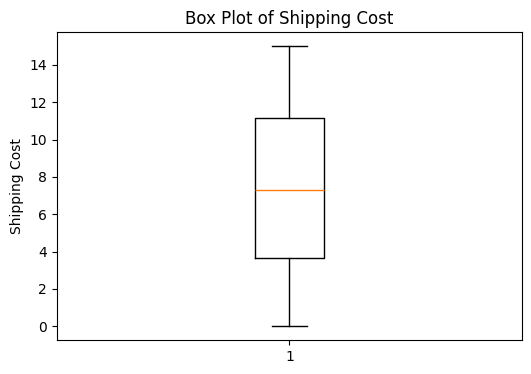

In [17]:
plt.figure(figsize=(6,4))

plt.boxplot(dataset["ShippingCost"])

plt.title("Box Plot of Shipping Cost")

plt.ylabel("Shipping Cost")

plt.show()

## Export Clean Dataset

In [19]:

dataset.to_csv("Amazon_Sales_Cleaned.csv", index=False)

print("Clean dataset exported successfully!")

Clean dataset exported successfully!
